In [1]:
import matplotlib.pyplot as plt
import numpy as np
import qutip as qt
from IPython.display import display, Math, Latex

import scipy
from scipy.fft import fft, ifft
import scipy.special as sp
import scipy.optimize 
import cmath

In [2]:
Delta = 0 #no detuning w0 - wp/2
w = 0 # ws-wp/2
kappa = 300e6*2*np.pi
drive = 0.2
theta = -np.pi/2
phi = 0
n_levels = 100
step = 40

In [3]:
lam_range = -np.linspace(0,1.96,step)*kappa/4

In [4]:
def gs(Delta, kappa, lam, w):
    num = kappa**2/2 - 1j*kappa * (Delta + w)
    denom = Delta**2 + (kappa/2 - 1j*w)**2 - lam**2

    return num/denom - 1

In [5]:
def gi(Delta, kappa, lam, w, theta):
    num = -1j * kappa * lam * np.exp(-1j*theta)
    denom = Delta**2 + (kappa/2 - 1j*w)**2 - lam**2

    return num/denom

In [6]:
np.abs(gs(Delta, kappa, lam_range[10], 0))**2 - np.abs(gi(Delta, kappa, lam_range[10], 0, theta))**2

np.float64(1.0000000000000002)

In [7]:
r1 = np.arccosh(gs(Delta, kappa, lam_range[29], 0))
r2 = -np.arcsinh(gi(Delta, kappa, lam_range[29], 0, np.pi/2))

In [8]:
r1

np.complex128(1.8519762833757616+0j)

In [9]:
r2

np.complex128(-1.8519762833757616-5.828900749960122e-17j)

In [10]:
def r_sq(Delta, kappa, lam, w):
    return np.arccosh(gs(Delta, kappa, lam, w))

In [224]:
r_sq(Delta, kappa, lam_range[29], w)

np.complex128(1.8519762833757616+0j)

In [12]:
lam_range[35]/kappa

np.float64(-0.43974358974358974)

In [13]:
np.exp(2*r_sq(Delta, kappa, lam_range[35], w))

np.complex128(243.22725215029425+0j)

In [14]:
def Sf_DPA_boutin(kappa, lam):
    return (kappa/2 + np.abs(lam))**2 / (kappa/2 - np.abs(lam))**2

In [15]:
Sf_DPA_boutin(kappa, lam_range[35])

np.float64(243.22725215029422)

In [16]:
def X_var_th(Delta, kappa, lam, w):
    r = r_sq(Delta, kappa, lam, w)
    return 0.5 * np.exp(-2*r)

In [17]:
def Sq_state(n, Delta, kappa, lam, w, sq_ang, alpha):
    a = qt.destroy(n)
    init_st = qt.coherent(n,alpha)
    r = r_sq(Delta, kappa, lam, w)
    eps = r * np.exp(1j * 2 * sq_ang)
    eps_c = r * np.exp(-1j * 2 * sq_ang)
    Sq_term = 0.5 * (eps_c * a*a - eps * a.dag()*a.dag())
    Sq_op = Sq_term.expm()
    Sq_state = Sq_op * init_st

    return Sq_state

In [18]:
def X_var(n, state):
    a = qt.destroy(n)
    X = (a+a.dag()) / np.sqrt(2)
    return qt.expect(X*X, state) - qt.expect(X,state)**2

In [19]:
def P_var(n, state):
    a = qt.destroy(n)
    P = 1j*(a.dag()-a) / np.sqrt(2)
    return qt.expect(P*P, state) - qt.expect(P,state)**2

In [229]:
r_sq(Delta, kappa, lam_range[0], w)

np.complex128(0j)

In [230]:
X_var(n_levels, qt.basis(n_levels,0))

0.4999999999999999

In [20]:
def Gain_get_DPA(Delta, kappa, lam, drive, n, theta, phi):
    
    a = qt.destroy(n)
        
    H_DPA = Delta * a.dag() * a + lam*np.exp(-1j*theta)/2 * a.dag() * a.dag() + np.conj(lam*np.exp(-1j*theta))/2 * a * a
    
    c_op_list = [np.sqrt(kappa) * a]
    epsilon = drive*kappa*np.exp(-1j*phi) #probe strength
    a_in = 1j * epsilon / np.sqrt(kappa)
    H_probe = epsilon * a.dag() + np.conj(epsilon) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_probe, c_op_list)
    a_exp = qt.expect(a, final_state)
    a_out = np.sqrt(kappa) * a_exp + a_in

    epsilon_2 = drive*kappa * 1j * np.exp(-1j*phi)
    a_in_2 = 1j * epsilon_2 / np.sqrt(kappa)
    H_probe = epsilon_2 * a.dag() + np.conj(epsilon_2) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_probe, c_op_list)
    a_exp_2 = qt.expect(a, final_state)
    a_out_2 = np.sqrt(kappa) * a_exp_2 + a_in_2
    
    def Gain_DPA_matrix(a_out, a_in, a_out_2, a_in_2):
        X_out = a_out + np.conj(a_out)
        X_out = X_out / np.sqrt(2)
        P_out = - a_out + np.conj(a_out)
        P_out = 1j * P_out / np.sqrt(2)
        X_in = a_in + np.conj(a_in)
        X_in = X_in / np.sqrt(2)
        P_in = - a_in + np.conj(a_in)
        P_in = 1j * P_in / np.sqrt(2)

        X_out_2 = a_out_2 + np.conj(a_out_2)
        X_out_2 = X_out_2 / np.sqrt(2)
        P_out_2 = - a_out_2 + np.conj(a_out_2)
        P_out_2 = 1j * P_out_2 / np.sqrt(2)
        X_in_2 = a_in_2 + np.conj(a_in_2)
        X_in_2 = X_in_2 / np.sqrt(2)
        P_in_2 = - a_in_2 + np.conj(a_in_2)
        P_in_2 = 1j * P_in_2 / np.sqrt(2)

        IN = np.array([[X_in,X_in_2],[P_in,P_in_2]])
        OUT = np.array([[X_out,X_out_2],[P_out,P_out_2]])
        Matrix = OUT @ scipy.linalg.inv(IN)
        # print(IN @ np.linalg.inv(IN))
        return Matrix

    g_DPA = Gain_DPA_matrix(a_out,a_in,a_out_2,a_in_2)
    Gain_DPA = 1/4 * np.abs(g_DPA[0,0] + g_DPA[1,1] + 1j*(g_DPA[1,0] - g_DPA[0,1]))**2

    vac = qt.basis(n,0)
    ain = ((1j*Delta + kappa/2)*a + 1j*lam*np.exp(-1j*theta)*a.dag() + 1j*epsilon) / np.sqrt(kappa)
    aind = ((-1j*Delta + kappa/2)*a.dag() - 1j*lam*np.exp(1j*theta)*a - 1j*np.conjugate(epsilon)) / np.sqrt(kappa)

    Xin = (ain+aind) / np.sqrt(2)
    Pin = 1j*(-ain+aind) / np.sqrt(2)
    Xnorm = lam**2/kappa + Delta**2/kappa + kappa/4 - 2*Delta*lam*np.cos(theta)/kappa + lam*np.sin(theta)
    Pnorm = lam**2/kappa + Delta**2/kappa + kappa/4 + 2*Delta*lam*np.cos(theta)/kappa - lam*np.sin(theta)
    Xin_var = (qt.expect(Xin*Xin,vac) - qt.expect(Xin,vac)**2) / Xnorm #/ 2 #figure out this factor of 1/2 --> solved and got rid of it
    Pin_var = (qt.expect(Pin*Pin,vac) - qt.expect(Pin,vac)**2) / Pnorm
    #Xout_var = np.abs(g_DPA[0,0])**2 * Xin_var + np.abs(g_DPA[0,1])**2 * Pin_var
    Xout_var = np.abs(g_DPA[0,0])**2 * 0.5 + np.abs(g_DPA[0,1])**2 * 0.5
    
    Xvac = 0.5
    Var_ratio = Xvac / Xout_var
    Var_ratio = 10 * np.log10(Var_ratio)

        
    return Gain_DPA, Xin_var, Xout_var, Var_ratio, g_DPA

In [21]:
Gain_get_DPA(Delta, kappa, lam_range[20], drive, 50, theta, phi)

(np.float64(2.80843396950233),
 np.float64(0.49999999999999994),
 np.float64(0.05479970646134442),
 np.float64(9.601917721757333),
 array([[-3.31058020e-01+0.j, -8.23440425e-17+0.j],
        [-8.23440425e-17+0.j, -3.02061856e+00+0.j]]))

In [201]:
lam_range[35]/kappa

np.float64(-0.43974358974358974)

In [202]:
np.abs(gs(Delta, kappa, lam_range[35], w))**2

np.float64(61.30784088292311)

In [203]:
np.cosh(r_sq(Delta, kappa, lam_range[35], w))**2

np.complex128(61.307840882923095+0j)

In [204]:
0.5*np.exp(-2*r_sq(Delta, kappa, lam_range[35], w))

np.complex128(0.0020556906990465097+0j)

In [205]:
0.5*np.exp(2*r_sq(Delta, kappa, lam_range[35], w))

np.complex128(121.61362607514712+0j)

In [206]:
X_var_th(Delta, kappa, lam_range[35], w)

np.complex128(0.0020556906990465097+0j)

In [207]:
Gain_get_DPA(Delta, kappa, lam_range[35], 0.2, 50, -np.pi/2, phi)[4]

array([[-6.41191375e-02+0.j, -4.61882953e-16+0.j],
       [-4.75430907e-16+0.j, -1.51488085e+01+0.j]])

In [233]:
# DPA
Sq_DPA=np.zeros(step)
Gain_DPA=np.zeros(step)
g_DPA11=np.zeros(step)
g_DPA12=np.zeros(step)
g_DPA21=np.zeros(step)
g_DPA22=np.zeros(step)
k = 0
for lam in lam_range:
    
    G_DPA, varXin_DPA, varXout_DPA, var_ratio_DPA, g_DPA = Gain_get_DPA(Delta, kappa, lam, drive, n_levels, theta, phi)

    Sq_DPA[k] = var_ratio_DPA
    Gain_DPA[k] = G_DPA

    g_DPA11[k]=g_DPA[0,0]
    g_DPA12[k]=g_DPA[0,1]
    g_DPA21[k]=g_DPA[1,0]
    g_DPA22[k]=g_DPA[1,1]
        
    k = k+1

C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\3253917222.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  g_DPA11[k]=g_DPA[0,0]
C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\3253917222.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  g_DPA12[k]=g_DPA[0,1]
C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\3253917222.py:18: ComplexWarning: Casting complex values to real discards the imaginary part
  g_DPA21[k]=g_DPA[1,0]
C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\3253917222.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  g_DPA22[k]=g_DPA[1,1]
C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\3253917222.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  g_DPA11[k]=g_DPA[0,0]
C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\3253917222.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  g_DPA12[k]=g_DPA[0,1

In [26]:
# JPA parameters
F_JPA = np.pi/4
EJ = 2000e9 * 2*np.pi
EC_J = 9e6 * 2*np.pi
phi_zpf_JPA = (2*EC_J/EJ)**0.25
JPA_ratio = phi_zpf_JPA**2/6 # |LAM/lam| ratio in abs value

Kerr = -EC_J * np.cos(F_JPA) / 2
print(Kerr/kappa)
print(JPA_ratio)

-0.010606601717798213
0.0005


In [22]:
def Gain_get_JPA(Delta, kappa, lam, Kerr, ratio, drive, n, theta, phi):
    
    a = qt.destroy(n)
    
    H_DPA = Delta * a.dag() * a + lam*np.exp(-1j*theta)/2 * a.dag() * a.dag() + np.conj(lam*np.exp(-1j*theta))/2 * a * a

    LAM = - ratio * lam
    H_alpha = Kerr * a.dag() * a.dag() * a * a  + LAM *(a.dag()*a.dag()*a.dag()*a + a.dag() * a * a * a)
  
    c_op_list = [np.sqrt(kappa) * a]

    epsilon = drive*kappa*np.exp(-1j*phi)
    a_in = 1j * epsilon / np.sqrt(kappa)
    H_probe = epsilon * a.dag() + np.conj(epsilon) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_alpha+H_probe, c_op_list)
    a_exp = qt.expect(a, final_state)
    a_out = np.sqrt(kappa) * a_exp + a_in

    epsilon_2 = drive*kappa * 1j*np.exp(-1j*phi)
    a_in_2 = 1j * epsilon_2 / np.sqrt(kappa)
    H_probe = epsilon_2 * a.dag() + np.conj(epsilon_2) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_alpha+H_probe, c_op_list)
    a_exp_2 = qt.expect(a, final_state)
    a_out_2 = np.sqrt(kappa) * a_exp_2 + a_in_2
    
    def Gain_JPA_matrix(a_out, a_in, a_out_2, a_in_2):
        X_out = a_out + np.conj(a_out)
        X_out = X_out / np.sqrt(2)
        P_out = - a_out + np.conj(a_out)
        P_out = 1j * P_out / np.sqrt(2)
        X_in = a_in + np.conj(a_in)
        X_in = X_in / np.sqrt(2)
        P_in = - a_in + np.conj(a_in)
        P_in = 1j * P_in / np.sqrt(2)

        X_out_2 = a_out_2 + np.conj(a_out_2)
        X_out_2 = X_out_2 / np.sqrt(2)
        P_out_2 = - a_out_2 + np.conj(a_out_2)
        P_out_2 = 1j * P_out_2 / np.sqrt(2)
        X_in_2 = a_in_2 + np.conj(a_in_2)
        X_in_2 = X_in_2 / np.sqrt(2)
        P_in_2 = - a_in_2 + np.conj(a_in_2)
        P_in_2 = 1j * P_in_2 / np.sqrt(2)

        IN = np.array([[X_in,X_in_2],[P_in,P_in_2]])
        OUT = np.array([[X_out,X_out_2],[P_out,P_out_2]])
        Matrix = OUT @ np.linalg.inv(IN)
        # print(IN @ np.linalg.inv(IN))
        return Matrix
    g_JPA = Gain_JPA_matrix(a_out,a_in,a_out_2,a_in_2)
    Gain_JPA = 1/4 * np.abs(g_JPA[0,0] + g_JPA[1,1] + 1j*(g_JPA[1,0] - g_JPA[0,1]))**2
    gsw = cmath.sqrt(Gain_JPA)
    
    lam_DPA = 1j * kappa * cmath.sqrt(-1+gsw) / cmath.sqrt(-4-4*gsw)
    lam_DPA = np.abs(lam_DPA)

    vac = qt.basis(n,0)
    ain = ((1j*Delta + kappa/2)*a + 1j*lam*np.exp(-1j*theta)*a.dag() + 1j*epsilon + 1j*2*Kerr*a.dag()*a*a + 1j*LAM*(a*a*a+3*a.dag()*a.dag()*a)) / np.sqrt(kappa)
    aind = ((-1j*Delta + kappa/2)*a.dag() - 1j*lam*np.exp(1j*theta)*a - 1j*np.conjugate(epsilon) - 1j*2*Kerr*a.dag()*a.dag()*a + 1j*LAM*(a.dag()*a.dag()*a.dag()+3*a.dag()*a*a)) / np.sqrt(kappa)

    Xin = (ain+aind) / np.sqrt(2)
    Pin = 1j*(-ain+aind) / np.sqrt(2)
    Xnorm = lam_DPA**2/kappa + Delta**2/kappa + kappa/4 - 2*Delta*lam_DPA*np.cos(theta)/kappa + lam_DPA*np.sin(theta)
    Pnorm = lam_DPA**2/kappa + Delta**2/kappa + kappa/4 + 2*Delta*lam_DPA*np.cos(theta)/kappa - lam_DPA*np.sin(theta)
    Xin_var = (qt.expect(Xin*Xin,vac) - qt.expect(Xin,vac)**2) / Xnorm #/ 2 #figure out this factor of 1/2
    Pin_var = (qt.expect(Pin*Pin,vac) - qt.expect(Pin,vac)**2) / Pnorm
    #Xout_var = np.abs(g_JPA[0,0])**2 * Xin_var + np.abs(g_JPA[0,1])**2 * Pin_var
    Xout_var = np.abs(g_JPA[0,0])**2 * 0.5 + np.abs(g_JPA[0,1])**2 * 0.5

    crossterm = qt.expect(Xin*Pin+Pin*Xin, vac)
    Xvac = 0.5
    Var_ratio = np.abs(Xvac / Xout_var)
    Var_ratio = 10 * np.log10(Var_ratio)
    
    return Gain_JPA, Xin_var, Xout_var, Var_ratio, g_JPA#, crossterm, Pin_var, Pnorm

In [ ]:
# Compare JPA, K free JPA, LAM free JPA and DPA

In [24]:
lam_range[32]/kappa

np.float64(-0.40205128205128204)

In [41]:
Kerr/kappa

np.float64(-0.010606601717798213)

In [42]:
JPA_ratio

0.0005

In [52]:
Gain_get_JPA(Delta, kappa, -0.45*kappa, Kerr, JPA_ratio, drive, n_levels, theta, phi)

(np.float64(30.209956393542274),
 (63.91203870958447+0j),
 np.float64(2.1365191806033343),
 np.float64(-6.30736791713895),
 array([[  0.01568699+0.j,   2.06707336+0.j],
        [ -0.41572884+0.j, -10.72435258+0.j]]))

In [53]:
Gain_get_JPA(Delta, kappa, -0.45*kappa, Kerr, 0, drive, n_levels, theta, phi)

(np.float64(30.61919379761328),
 (64.7183203776462+0j),
 np.float64(2.0467470782387376),
 np.float64(-6.120941747643225),
 array([[  0.01412784+0.j,   2.02318921+0.j],
        [ -0.41798751+0.j, -10.80845188+0.j]]))

In [54]:
Gain_get_JPA(Delta, kappa, -0.45*kappa, 0, JPA_ratio, drive, n_levels, theta, phi)

(np.float64(90.59082101733024),
 (180.19617442861482+0j),
 np.float64(0.09339585985162609),
 np.float64(7.286423795346753),
 array([[-5.25918574e-02+0.j,  4.28982303e-01+0.j],
        [-5.88172738e-03+0.j, -1.89782825e+01+0.j]]))

In [55]:
Gain_get_DPA(Delta, kappa, -0.45*kappa, drive, n_levels, theta, phi)

(np.float64(90.57859604918842),
 np.float64(0.49999999999999983),
 np.float64(0.0013850415350113742),
 np.float64(25.575072069963657),
 array([[-5.26315786e-02+0.j, -5.79543615e-16+0.j],
        [-5.80095779e-16+0.j, -1.89819261e+01+0.j]]))

In [236]:
# JPA
Sq_JPA=np.zeros(step)
Gain_JPA=np.zeros(step)
g_JPA11=np.zeros(step)
g_JPA12=np.zeros(step)
g_JPA21=np.zeros(step)
g_JPA22=np.zeros(step)
k = 0
for lam in lam_range:
    
    G_JPA, varXin_JPA, varXout_JPA, var_ratio_JPA, g_JPA = Gain_get_JPA(Delta, kappa, lam, Kerr, JPA_ratio, drive, n_levels, theta, phi)

    Sq_JPA[k] = var_ratio_JPA
    Gain_JPA[k] = G_JPA

    g_JPA11[k]=g_JPA[0,0]
    g_JPA12[k]=g_JPA[0,1]
    g_JPA21[k]=g_JPA[1,0]
    g_JPA22[k]=g_JPA[1,1]
    
    k = k+1

C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\3415380592.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  g_JPA11[k]=g_JPA[0,0]
C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\3415380592.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  g_JPA12[k]=g_JPA[0,1]
C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\3415380592.py:18: ComplexWarning: Casting complex values to real discards the imaginary part
  g_JPA21[k]=g_JPA[1,0]
C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\3415380592.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  g_JPA22[k]=g_JPA[1,1]
C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\3415380592.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  g_JPA11[k]=g_JPA[0,0]
C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\3415380592.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  g_JPA12[k]=g_JPA[0,1

In [237]:
# KFJPA
Sq_KFJPA=np.zeros(step)
Gain_KFJPA=np.zeros(step)
g_KFJPA11=np.zeros(step)
g_KFJPA12=np.zeros(step)
g_KFJPA21=np.zeros(step)
g_KFJPA22=np.zeros(step)
k = 0
for lam in lam_range:
    
    G_KFJPA, varXin_KFJPA, varXout_KFJPA, var_ratio_KFJPA, g_KFJPA = Gain_get_JPA(Delta, kappa, lam, 0, JPA_ratio, drive, n_levels, theta, phi)

    Sq_KFJPA[k] = var_ratio_KFJPA
    Gain_KFJPA[k] = G_KFJPA

    g_KFJPA11[k]=g_KFJPA[0,0]
    g_KFJPA12[k]=g_KFJPA[0,1]
    g_KFJPA21[k]=g_KFJPA[1,0]
    g_KFJPA22[k]=g_KFJPA[1,1]
    
    k = k+1

C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\182331828.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  g_KFJPA11[k]=g_KFJPA[0,0]
C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\182331828.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  g_KFJPA12[k]=g_KFJPA[0,1]
C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\182331828.py:18: ComplexWarning: Casting complex values to real discards the imaginary part
  g_KFJPA21[k]=g_KFJPA[1,0]
C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\182331828.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  g_KFJPA22[k]=g_KFJPA[1,1]
C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\182331828.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  g_KFJPA11[k]=g_KFJPA[0,0]
C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\182331828.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  g_KFJP

In [238]:
# LAM-free JPA
Sq_LFJPA=np.zeros(step)
Gain_LFJPA=np.zeros(step)
g_LFJPA11=np.zeros(step)
g_LFJPA12=np.zeros(step)
g_LFJPA21=np.zeros(step)
g_LFJPA22=np.zeros(step)
k = 0
for lam in lam_range:
    
    G_LFJPA, varXin_LFJPA, varXout_LFJPA, var_ratio_LFJPA, g_LFJPA = Gain_get_JPA(Delta, kappa, lam, Kerr, 0, drive, n_levels, theta, phi)

    Sq_LFJPA[k] = var_ratio_LFJPA
    Gain_LFJPA[k] = G_LFJPA

    g_LFJPA11[k]=g_LFJPA[0,0]
    g_LFJPA12[k]=g_LFJPA[0,1]
    g_LFJPA21[k]=g_LFJPA[1,0]
    g_LFJPA22[k]=g_LFJPA[1,1]
    
    k = k+1

C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\215308087.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  g_LFJPA11[k]=g_LFJPA[0,0]
C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\215308087.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  g_LFJPA12[k]=g_LFJPA[0,1]
C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\215308087.py:18: ComplexWarning: Casting complex values to real discards the imaginary part
  g_LFJPA21[k]=g_LFJPA[1,0]
C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\215308087.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  g_LFJPA22[k]=g_LFJPA[1,1]
C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\215308087.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  g_LFJPA11[k]=g_LFJPA[0,0]
C:\Users\kagan\AppData\Local\Temp\ipykernel_19516\215308087.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  g_LFJP

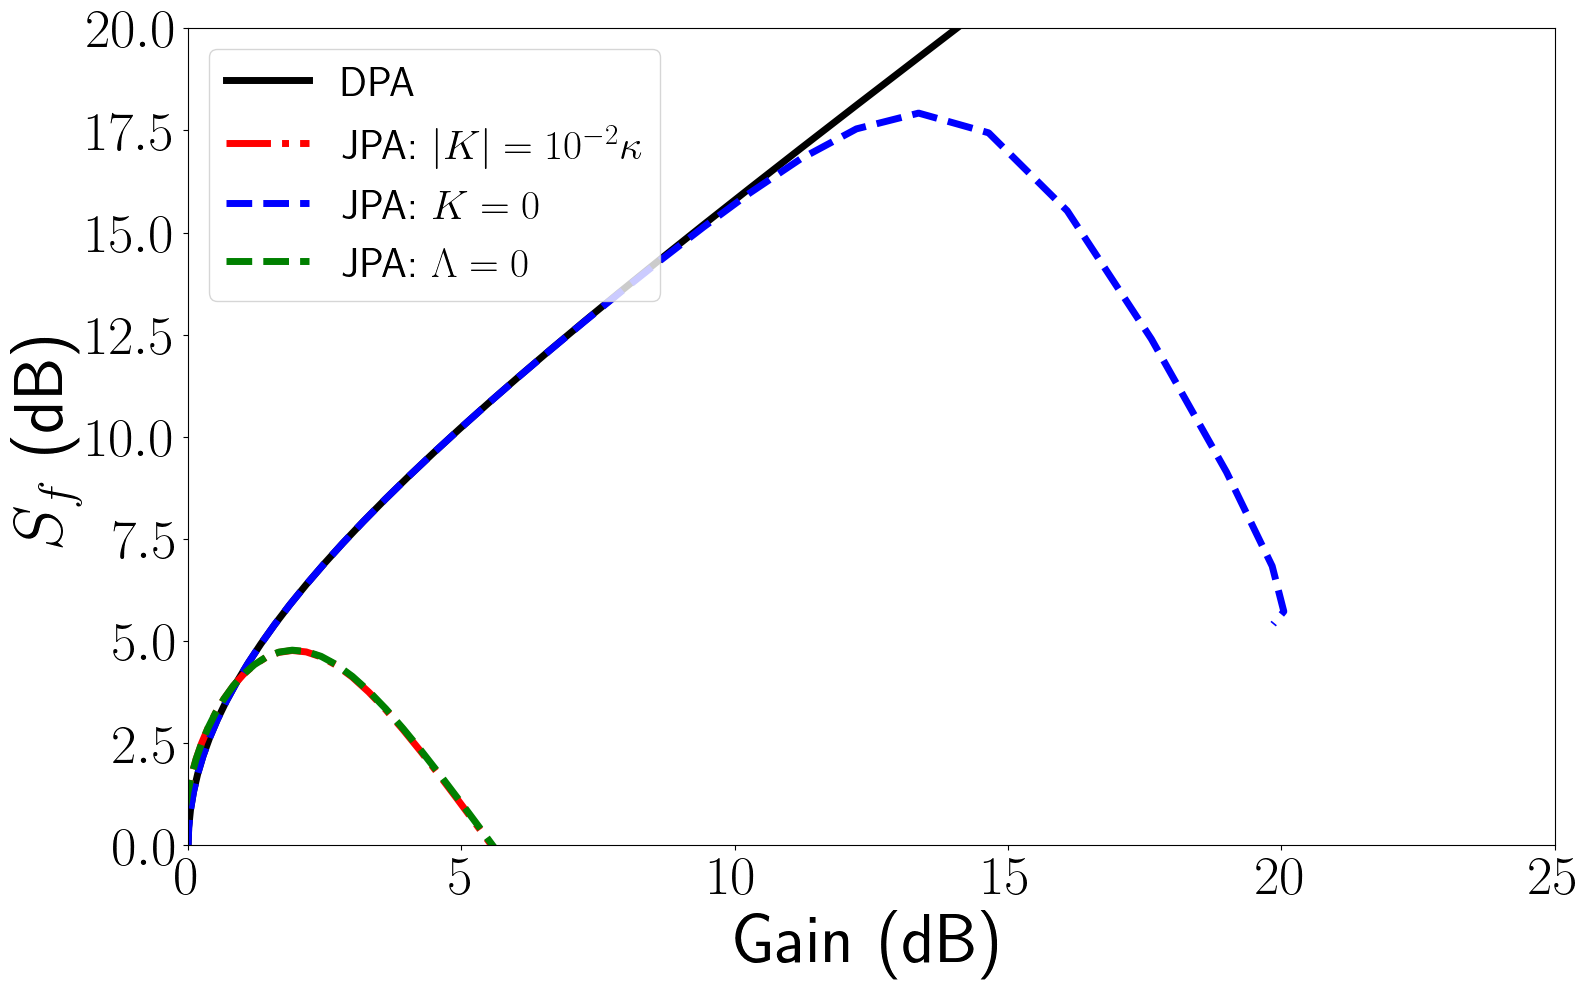

In [176]:
plt.figure(figsize=(16,10))
plt.rcParams['text.usetex'] = True
plt.plot(10*np.log10(Gain_DPA), Sq_DPA, c='black', linewidth=5, label = r'DPA')
plt.plot(10*np.log10(Gain_JPA), Sq_JPA, '-.', c='red', linewidth=5, label = r'JPA: $|K|=10^{-2}\kappa$')
plt.plot(10*np.log10(Gain_KFJPA), Sq_KFJPA, '--', c='blue', linewidth=5, label = r'JPA: $K=0$')
plt.plot(10*np.log10(Gain_LFJPA), Sq_LFJPA, '--', c='green', linewidth=5, label = r'JPA: $\Lambda=0$')





plt.legend(loc='upper left', fontsize=30)
plt.xlabel(r'Gain (dB)',fontsize=50)
plt.ylabel(r'$S_f$ (dB)', fontsize=50)
#plt.xscale('log')
#plt.yscale('log')
plt.xlim(0,25)
plt.ylim(0,20)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
plt.tight_layout()
#plt.savefig("Squeezing level.jpeg")

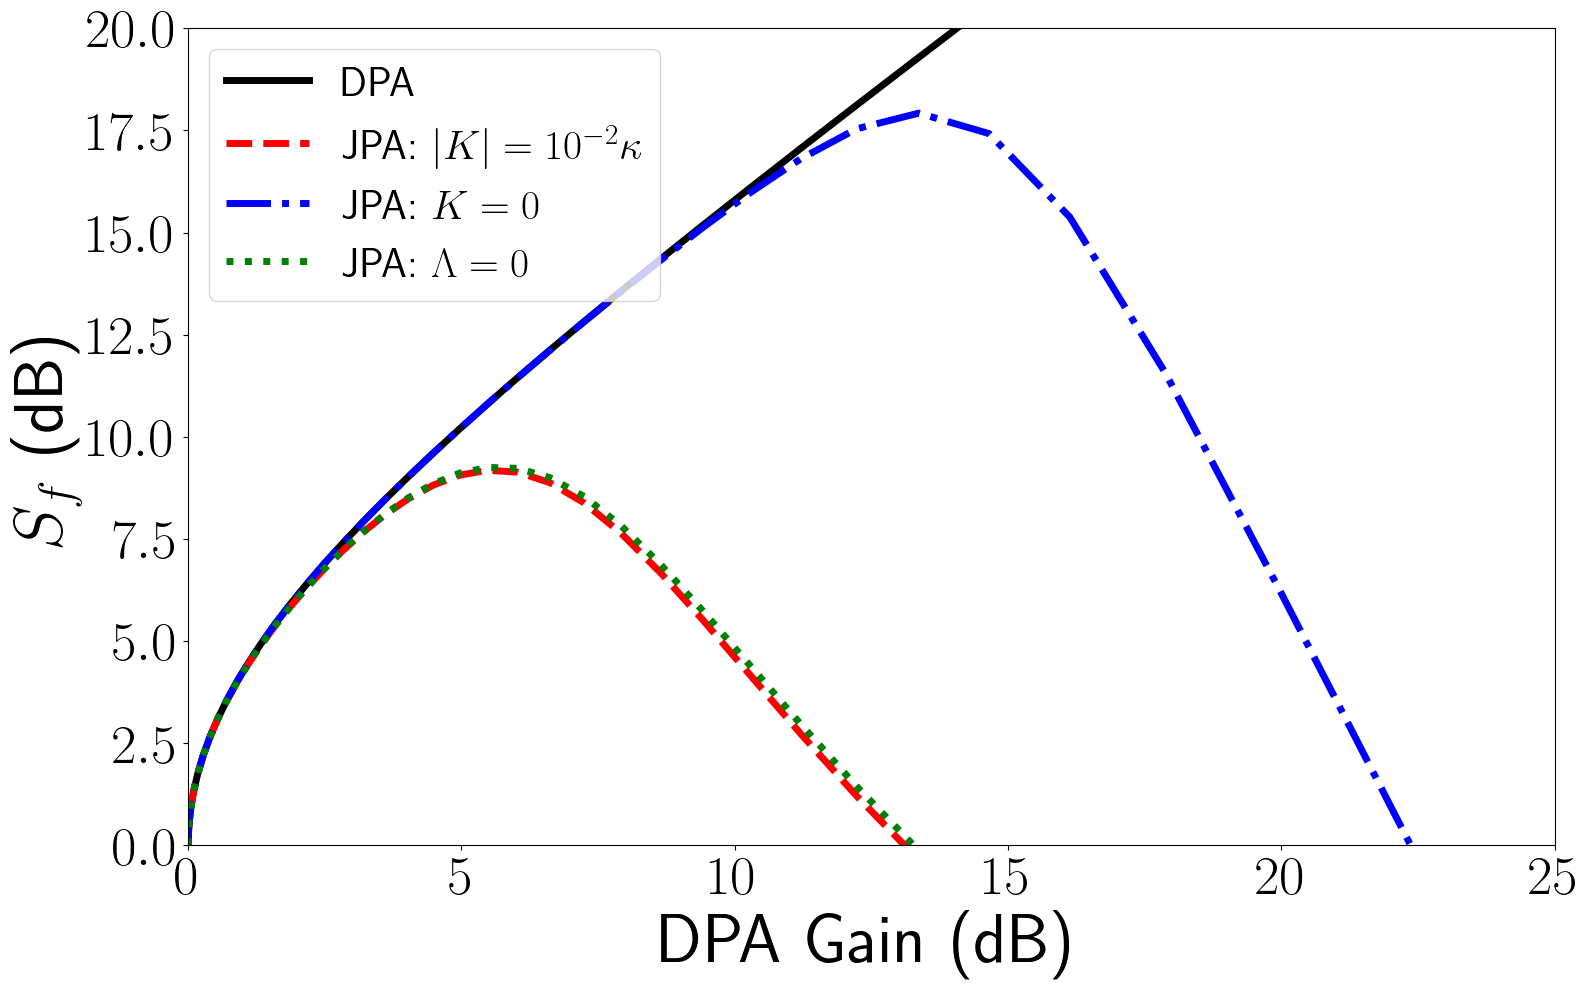

In [239]:
plt.figure(figsize=(16,10))
plt.rcParams['text.usetex'] = True
plt.plot(10*np.log10(Gain_DPA), Sq_DPA, c='black', linewidth=5, label = r'DPA')
plt.plot(10*np.log10(Gain_DPA), Sq_JPA, '--', c='red', linewidth=5, label = r'JPA: $|K|=10^{-2}\kappa$')
plt.plot(10*np.log10(Gain_DPA), Sq_KFJPA, '-.', c='blue', linewidth=5, label = r'JPA: $K=0$')
plt.plot(10*np.log10(Gain_DPA), Sq_LFJPA, linestyle='dotted', c='green', linewidth=5, label = r'JPA: $\Lambda=0$')





plt.legend(loc='upper left', fontsize=30)
plt.xlabel(r'DPA Gain (dB)',fontsize=50)
plt.ylabel(r'$S_f$ (dB)', fontsize=50)
#plt.xscale('log')
#plt.yscale('log')
plt.xlim(0,25)
plt.ylim(0,20)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
plt.tight_layout()
plt.savefig("Squeezing level.jpeg")

In [23]:
# KFJPA parameters

EC = EC_J#1e6 * 2*np.pi #5e6 * 2*np.pi#85e4 * 2*np.pi #2e6 * 2*np.pi
EL = EJ#2000e9 * 2*np.pi #1650e9 * 2*np.pi#140e9 * 2*np.pi #70e9 * 2*np.pi
phi_zps = (2*EC/EL)**0.25 
STS_ratio = phi_zps**2/6 # |LAM/lam| ratio in abs value
print(STS_ratio/JPA_ratio)
print(STS_ratio)

1.0
0.00033636017896014446


In [24]:
def Gain_get_KFJPA(Delta, kappa,lam, drive, n_levels, theta, phi):
        
    a = qt.destroy(n_levels) 
    
    
    H_DPA = Delta * a.dag() * a + lam*np.exp(-1j*theta)/2 * a.dag()*a.dag() + lam*np.exp(1j*theta)/2 * a * a

    LAM = - STS_ratio * lam 
    H_alpha =  LAM * (a.dag()*a.dag()*a.dag()*a + a.dag() * a * a * a) 
    
    c_op_list = [np.sqrt(kappa) * a]

    epsilon = drive*kappa*np.exp(-1j*phi)
    a_in = 1j * epsilon / np.sqrt(kappa)
    H_probe = epsilon * a.dag() + np.conj(epsilon) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_alpha+H_probe, c_op_list)
    a_exp = qt.expect(a, final_state)
    a_out = np.sqrt(kappa) * a_exp + a_in

    epsilon_2 = drive*kappa * 1j*np.exp(-1j*phi)
    a_in_2 = 1j * epsilon_2 / np.sqrt(kappa)
    H_probe = epsilon_2 * a.dag() + np.conj(epsilon_2) * a
    H_probe = H_probe
    final_state = qt.steadystate(H_DPA+H_alpha+H_probe, c_op_list)
    a_exp_2 = qt.expect(a, final_state)
    a_out_2 = np.sqrt(kappa) * a_exp_2 + a_in_2
    
    
    def Gain_matrix(a_out, a_in, a_out_2, a_in_2):
        X_out = a_out + np.conj(a_out)
        X_out = X_out / np.sqrt(2)
        P_out = - a_out + np.conj(a_out)
        P_out = 1j * P_out / np.sqrt(2)
        X_in = a_in + np.conj(a_in)
        X_in = X_in / np.sqrt(2)
        P_in = - a_in + np.conj(a_in)
        P_in = 1j * P_in / np.sqrt(2)

        X_out_2 = a_out_2 + np.conj(a_out_2)
        X_out_2 = X_out_2 / np.sqrt(2)
        P_out_2 = - a_out_2 + np.conj(a_out_2)
        P_out_2 = 1j * P_out_2 / np.sqrt(2)
        X_in_2 = a_in_2 + np.conj(a_in_2)
        X_in_2 = X_in_2 / np.sqrt(2)
        P_in_2 = - a_in_2 + np.conj(a_in_2)
        P_in_2 = 1j * P_in_2 / np.sqrt(2)

        IN = np.array([[X_in,X_in_2],[P_in,P_in_2]])
        OUT = np.array([[X_out,X_out_2],[P_out,P_out_2]])
        Matrix = OUT @ np.linalg.inv(IN)
        # print(IN @ np.linalg.inv(IN))
        return Matrix
    g_KFJPA = Gain_matrix(a_out,a_in,a_out_2,a_in_2)
    Gain_KFJPA = 1/4 * np.abs(g_KFJPA[0,0] + g_KFJPA[1,1] + 1j*(g_KFJPA[1,0] - g_KFJPA[0,1]))**2
    Xout_var = np.abs(g_KFJPA[0,0])**2 * 0.5 + np.abs(g_KFJPA[0,1])**2 * 0.5

    Xvac = 0.5
    Var_ratio = np.abs(Xvac / Xout_var)
    Var_ratio = 10 * np.log10(Var_ratio)

    return Gain_KFJPA, Var_ratio, g_KFJPA

In [25]:
# KFJPA
Sq_KFJPA=np.zeros(step)
Gain_KFJPA=np.zeros(step)
g_KFJPA11=np.zeros(step)
g_KFJPA12=np.zeros(step)
g_KFJPA21=np.zeros(step)
g_KFJPA22=np.zeros(step)
k = 0
for lam in lam_range:
    
    G_KFJPA, var_ratio_KFJPA, g_KFJPA = Gain_get_KFJPA(Delta, kappa, lam, drive, n_levels, theta, phi)

    Sq_KFJPA[k] = var_ratio_KFJPA
    Gain_KFJPA[k] = G_KFJPA

    g_KFJPA11[k]=g_KFJPA[0,0]
    g_KFJPA12[k]=g_KFJPA[0,1]
    g_KFJPA21[k]=g_KFJPA[1,0]
    g_KFJPA22[k]=g_KFJPA[1,1]
    
    k = k+1

C:\Users\kagan\AppData\Local\Temp\ipykernel_22252\2225498899.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  g_KFJPA11[k]=g_KFJPA[0,0]
C:\Users\kagan\AppData\Local\Temp\ipykernel_22252\2225498899.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  g_KFJPA12[k]=g_KFJPA[0,1]
C:\Users\kagan\AppData\Local\Temp\ipykernel_22252\2225498899.py:18: ComplexWarning: Casting complex values to real discards the imaginary part
  g_KFJPA21[k]=g_KFJPA[1,0]
C:\Users\kagan\AppData\Local\Temp\ipykernel_22252\2225498899.py:19: ComplexWarning: Casting complex values to real discards the imaginary part
  g_KFJPA22[k]=g_KFJPA[1,1]
C:\Users\kagan\AppData\Local\Temp\ipykernel_22252\2225498899.py:16: ComplexWarning: Casting complex values to real discards the imaginary part
  g_KFJPA11[k]=g_KFJPA[0,0]
C:\Users\kagan\AppData\Local\Temp\ipykernel_22252\2225498899.py:17: ComplexWarning: Casting complex values to real discards the imaginary part
  

C:\Users\kagan\AppData\Local\Temp\ipykernel_13208\2490582313.py:3: RuntimeWarning: divide by zero encountered in log10
  plt.plot(lam_range/kappa, 10*np.log10(np.abs(g_DPA12)**2), c='black', linewidth=5, label = 'DPA')
C:\Users\kagan\AppData\Local\Temp\ipykernel_13208\2490582313.py:5: RuntimeWarning: divide by zero encountered in log10
  plt.plot(lam_range/kappa, 10*np.log10(np.abs(g_KFJPA12)**2), '--', c='blue', linewidth=5, label = 'STS')


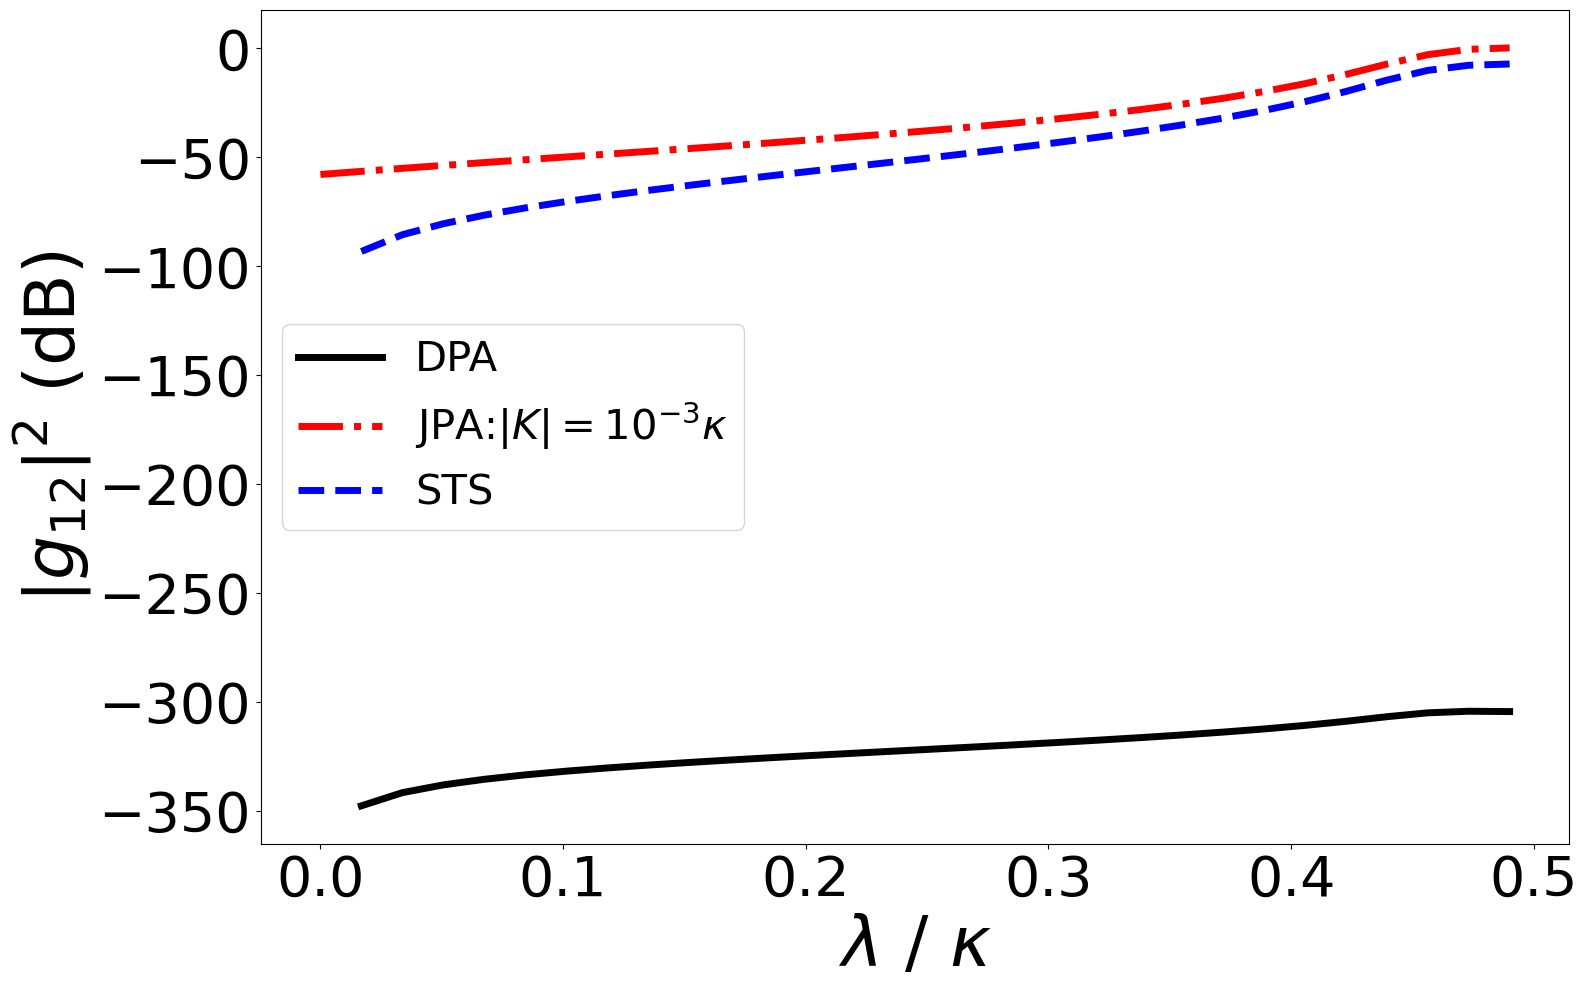

In [104]:
plt.figure(figsize=(16,10))
#plt.rcParams['text.usetex'] = True
plt.plot(lam_range/kappa, 10*np.log10(np.abs(g_DPA12)**2), c='black', linewidth=5, label = 'DPA')
plt.plot(lam_range/kappa, 10*np.log10(np.abs(g_JPA12)**2), '-.', c='red', linewidth=5, label = 'JPA:$|K|=10^{-3}\kappa$')
plt.plot(lam_range/kappa, 10*np.log10(np.abs(g_KFJPA12)**2), '--', c='blue', linewidth=5, label = 'STS')





plt.legend(loc='center left', fontsize=30)
plt.xlabel(r'$\lambda$ / $\kappa$',fontsize=50)
plt.ylabel(r'$|g_{12}|^2$ (dB)', fontsize=50)
#plt.xscale('log')
#plt.yscale('log')
#plt.xlim(0,25)
#plt.ylim(0,25)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
plt.tight_layout()
#plt.savefig("Deviation from DPA.jpeg")

In [108]:
Sq_DPA

array([2.79654965e-14, 5.87269951e-01, 1.17588529e+00, 1.76721001e+00,
       2.36264589e+00, 2.96365311e+00, 3.57177293e+00, 4.18865337e+00,
       4.81607916e+00, 5.45600725e+00, 6.11060994e+00, 6.78232812e+00,
       7.47393828e+00, 8.18863807e+00, 8.93015780e+00, 9.70290799e+00,
       1.05121788e+01, 1.13644149e+01, 1.22676042e+01, 1.32318408e+01,
       1.42701683e+01, 1.53998886e+01, 1.66446826e+01, 1.80382379e+01,
       1.96308833e+01, 2.15028296e+01, 2.37940029e+01, 2.67858908e+01,
       3.12435847e+01, 4.22343469e+01])

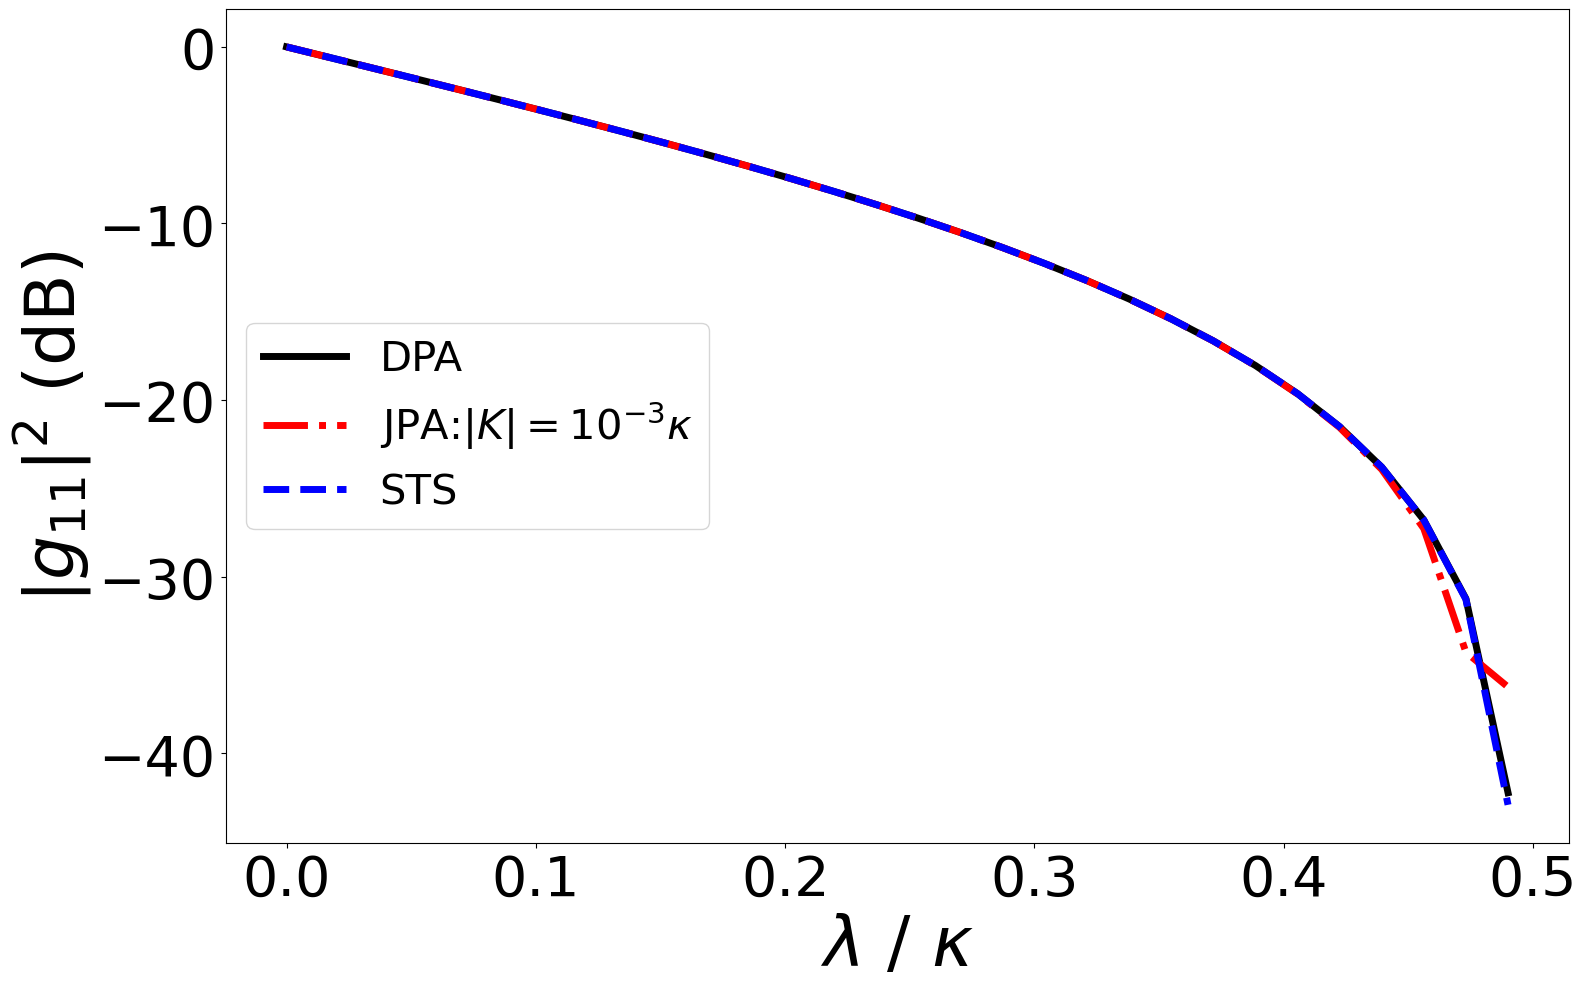

In [105]:
plt.figure(figsize=(16,10))
#plt.rcParams['text.usetex'] = True
plt.plot(lam_range/kappa, 10*np.log10(np.abs(g_DPA11)**2), c='black', linewidth=5, label = 'DPA')
plt.plot(lam_range/kappa, 10*np.log10(np.abs(g_JPA11)**2), '-.', c='red', linewidth=5, label = 'JPA:$|K|=10^{-3}\kappa$')
plt.plot(lam_range/kappa, 10*np.log10(np.abs(g_KFJPA11)**2), '--', c='blue', linewidth=5, label = 'STS')





plt.legend(loc='center left', fontsize=30)
plt.xlabel(r'$\lambda$ / $\kappa$',fontsize=50)
plt.ylabel(r'$|g_{11}|^2$ (dB)', fontsize=50)
#plt.xscale('log')
#plt.yscale('log')
#plt.xlim(0,25)
#plt.ylim(0,25)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
plt.tight_layout()
#plt.savefig("Deviation from DPA.jpeg")

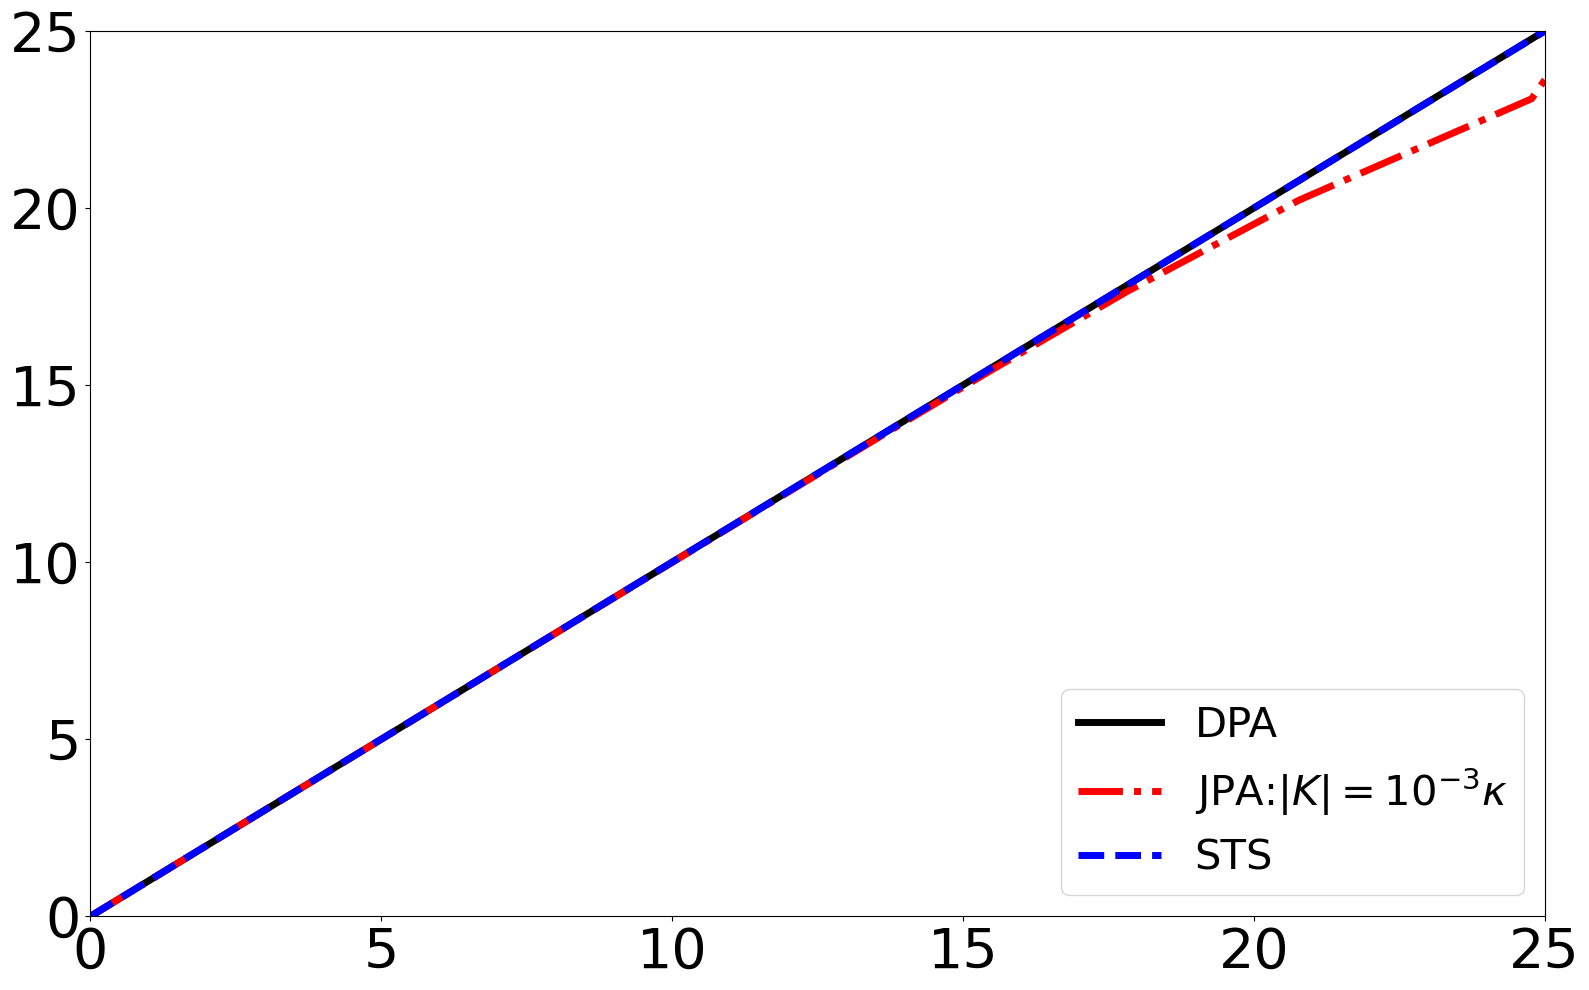

In [561]:
plt.figure(figsize=(16,10))
#plt.rcParams['text.usetex'] = True
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain_DPA), c='black', linewidth=5, label = 'DPA')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain_JPA), '-.', c='red', linewidth=5, label = 'JPA:$|K|=10^{-3}\kappa$')
plt.plot(10*np.log10(Gain_DPA), 10*np.log10(Gain_KFJPA), '--', c='blue', linewidth=5, label = 'STS')





plt.legend(loc='lower right', fontsize=30)
#plt.xlabel(r'$\Lambda$ / $\kappa$',fontsize=50)
#plt.ylabel(r'$\Xi_{\mu}$', fontsize=50)
#plt.xscale('log')
#plt.yscale('log')
plt.xlim(0,25)
plt.ylim(0,25)
plt.xticks(fontsize=40)
plt.yticks(fontsize=40)
plt.tight_layout()
#plt.savefig("Deviation from DPA.jpeg")